# 03 - Backtesting & Evaluation

Simulation der Optimierungsstrategie auf historischen Daten:
1. **Baseline (Ist-Zustand)**: Tatsächliches Verhalten ohne Optimierung
2. **Optimiert**: Simulierte Batterie-Steuerung mit PV-Prognose
3. **Vergleich**: Eigenverbrauchsquote, Netzbezug, Kosteneinsparung

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from src.data.evcc_connector import get_energy_history
from src.data.weather_connector import get_historical
from src.features.feature_engineering import reconstruct_pv_hourly, merge_weather, build_training_dataset
from src.models.pv_forecast import PVForecastModel

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 100

# Konfiguration
BATTERY_CAPACITY_KWH = 10.0
BATTERY_MIN_SOC = 10       # Minimum SoC in %
BATTERY_MAX_SOC = 100      # Maximum SoC in %
FEEDIN_PRICE = 0.079       # EUR/kWh Einspeisevergütung
GRID_PRICE = 0.2586        # EUR/kWh Netzbezugspreis

## 1. Daten laden & aufbereiten

In [2]:
# Daten laden
energy_raw = get_energy_history()

home = energy_raw[energy_raw["source"] == "home"].copy().sort_values("start").reset_index(drop=True)
grid = energy_raw[energy_raw["source"].str.startswith("db:3")].copy().sort_values("start").reset_index(drop=True)

# Ausreißer filtern
def filter_outliers(df, column, percentile=99.5):
    thresh = df[column].quantile(percentile / 100)
    return df[df[column] <= thresh].copy()

home = filter_outliers(home, "import")
grid = filter_outliers(grid, "import")
grid = filter_outliers(grid, "export")

# Stündliche PV-Rekonstruktion
hourly = reconstruct_pv_hourly(home, grid)

# Wetter dazu
from datetime import date, timedelta
weather = get_historical(
    start_date=hourly["timestamp"].min().date(),
    end_date=date.today() - timedelta(days=1)
)

hourly_w = merge_weather(hourly, weather)
print(f"Backtesting-Daten: {len(hourly_w)} Stunden")
print(f"Zeitraum: {hourly_w['timestamp'].min()} bis {hourly_w['timestamp'].max()}")
print(f"PV Ø: {hourly_w['pv_kwh'].mean():.2f} kWh/h, Verbrauch Ø: {hourly_w['consumption_kwh'].mean():.2f} kWh/h")

Backtesting-Daten: 337 Stunden
Zeitraum: 2026-04-19 14:00:00+00:00 bis 2026-05-03 14:00:00+00:00
PV Ø: 2.09 kWh/h, Verbrauch Ø: 0.61 kWh/h


## 2. Backtesting-Simulation

In [3]:
def simulate_battery(df, battery_kwh=BATTERY_CAPACITY_KWH, strategy="none"):
    """Simuliert Batterie-Verhalten über die historischen Daten.
    
    strategy: 
      'none'      - Keine Batterie-Optimierung (Baseline)
      'optimized' - Überschuss in Batterie, bei Bedarf entladen
    """
    results = []
    soc = 50.0  # Startwert %
    soc_kwh = battery_kwh * soc / 100
    min_kwh = battery_kwh * BATTERY_MIN_SOC / 100
    max_kwh = battery_kwh * BATTERY_MAX_SOC / 100
    
    for _, row in df.iterrows():
        pv = row["pv_kwh"]
        consumption = row["consumption_kwh"]
        surplus = max(0, pv - consumption)
        deficit = max(0, consumption - pv)
        
        battery_charge = 0
        battery_discharge = 0
        grid_import = 0
        grid_export = 0
        
        if strategy == "none":
            # Baseline: Überschuss geht direkt ins Netz
            grid_export = surplus
            grid_import = deficit
            
        elif strategy == "optimized":
            # Optimiert: Überschuss erst in Batterie, Rest ins Netz
            if surplus > 0:
                charge_possible = min(surplus, max_kwh - soc_kwh)
                battery_charge = charge_possible
                soc_kwh += charge_possible
                grid_export = surplus - charge_possible
            
            if deficit > 0:
                discharge_possible = min(deficit, soc_kwh - min_kwh)
                battery_discharge = discharge_possible
                soc_kwh -= discharge_possible
                grid_import = deficit - discharge_possible
        
        self_consumed = min(pv, consumption)
        if strategy == "optimized":
            self_consumed += battery_discharge  # Batterie-Entladung = vermiedener Netzbezug
        
        results.append({
            "timestamp": row["timestamp"],
            "pv_kwh": pv,
            "consumption_kwh": consumption,
            "surplus_kwh": surplus,
            "deficit_kwh": deficit,
            "battery_charge_kwh": battery_charge,
            "battery_discharge_kwh": battery_discharge,
            "battery_soc_pct": soc_kwh / battery_kwh * 100,
            "grid_import_kwh": grid_import,
            "grid_export_kwh": grid_export,
            "self_consumed_kwh": self_consumed,
        })
    
    return pd.DataFrame(results)


# Simulationen laufen lassen
baseline = simulate_battery(hourly_w, strategy="none")
optimized = simulate_battery(hourly_w, strategy="optimized")
print("Simulation abgeschlossen.")

Simulation abgeschlossen.


## 3. Ergebnisse vergleichen

In [4]:
def compute_metrics(sim, label):
    total_pv = sim["pv_kwh"].sum()
    total_consumption = sim["consumption_kwh"].sum()
    total_self = sim["self_consumed_kwh"].sum()
    total_import = sim["grid_import_kwh"].sum()
    total_export = sim["grid_export_kwh"].sum()
    
    self_consumption_rate = total_self / total_pv * 100 if total_pv > 0 else 0
    autarky_rate = total_self / total_consumption * 100 if total_consumption > 0 else 0
    
    cost_import = total_import * GRID_PRICE
    revenue_export = total_export * FEEDIN_PRICE
    net_cost = cost_import - revenue_export
    
    return {
        "Szenario": label,
        "PV Erzeugung (kWh)": round(total_pv, 1),
        "Verbrauch (kWh)": round(total_consumption, 1),
        "Eigenverbrauch (kWh)": round(total_self, 1),
        "Eigenverbrauchsquote (%)": round(self_consumption_rate, 1),
        "Autarkiequote (%)": round(autarky_rate, 1),
        "Netzbezug (kWh)": round(total_import, 1),
        "Einspeisung (kWh)": round(total_export, 1),
        "Kosten Bezug (EUR)": round(cost_import, 2),
        "Erlös Einspeisung (EUR)": round(revenue_export, 2),
        "Netto-Kosten (EUR)": round(net_cost, 2),
    }

m_base = compute_metrics(baseline, "Ohne Batterie")
m_opt = compute_metrics(optimized, "Mit Batterie-Optimierung")

comparison = pd.DataFrame([m_base, m_opt]).set_index("Szenario").T
print(comparison.to_string())

# Einsparung
saving = m_base["Netto-Kosten (EUR)"] - m_opt["Netto-Kosten (EUR)"]
ev_improvement = m_opt["Eigenverbrauchsquote (%)"] - m_base["Eigenverbrauchsquote (%)"] 
print(f"\n=== Verbesserung ===")
print(f"Eigenverbrauchsquote: +{ev_improvement:.1f} Prozentpunkte")
print(f"Kosteneinsparung: {saving:.2f} EUR im Zeitraum")
days = (hourly_w['timestamp'].max() - hourly_w['timestamp'].min()).total_seconds() / 86400
print(f"Hochgerechnet pro Jahr: ~{saving / days * 365:.0f} EUR")

Szenario                  Ohne Batterie  Mit Batterie-Optimierung
PV Erzeugung (kWh)               703.10                    703.10
Verbrauch (kWh)                  205.00                    205.00
Eigenverbrauch (kWh)             173.40                    202.00
Eigenverbrauchsquote (%)          24.70                     28.70
Autarkiequote (%)                 84.60                     98.50
Netzbezug (kWh)                   31.60                      3.00
Einspeisung (kWh)                529.70                    496.10
Kosten Bezug (EUR)                 8.18                      0.79
Erlös Einspeisung (EUR)           41.85                     39.19
Netto-Kosten (EUR)               -33.67                    -38.41

=== Verbesserung ===
Eigenverbrauchsquote: +4.0 Prozentpunkte
Kosteneinsparung: 4.74 EUR im Zeitraum
Hochgerechnet pro Jahr: ~124 EUR


## 4. Visualisierung

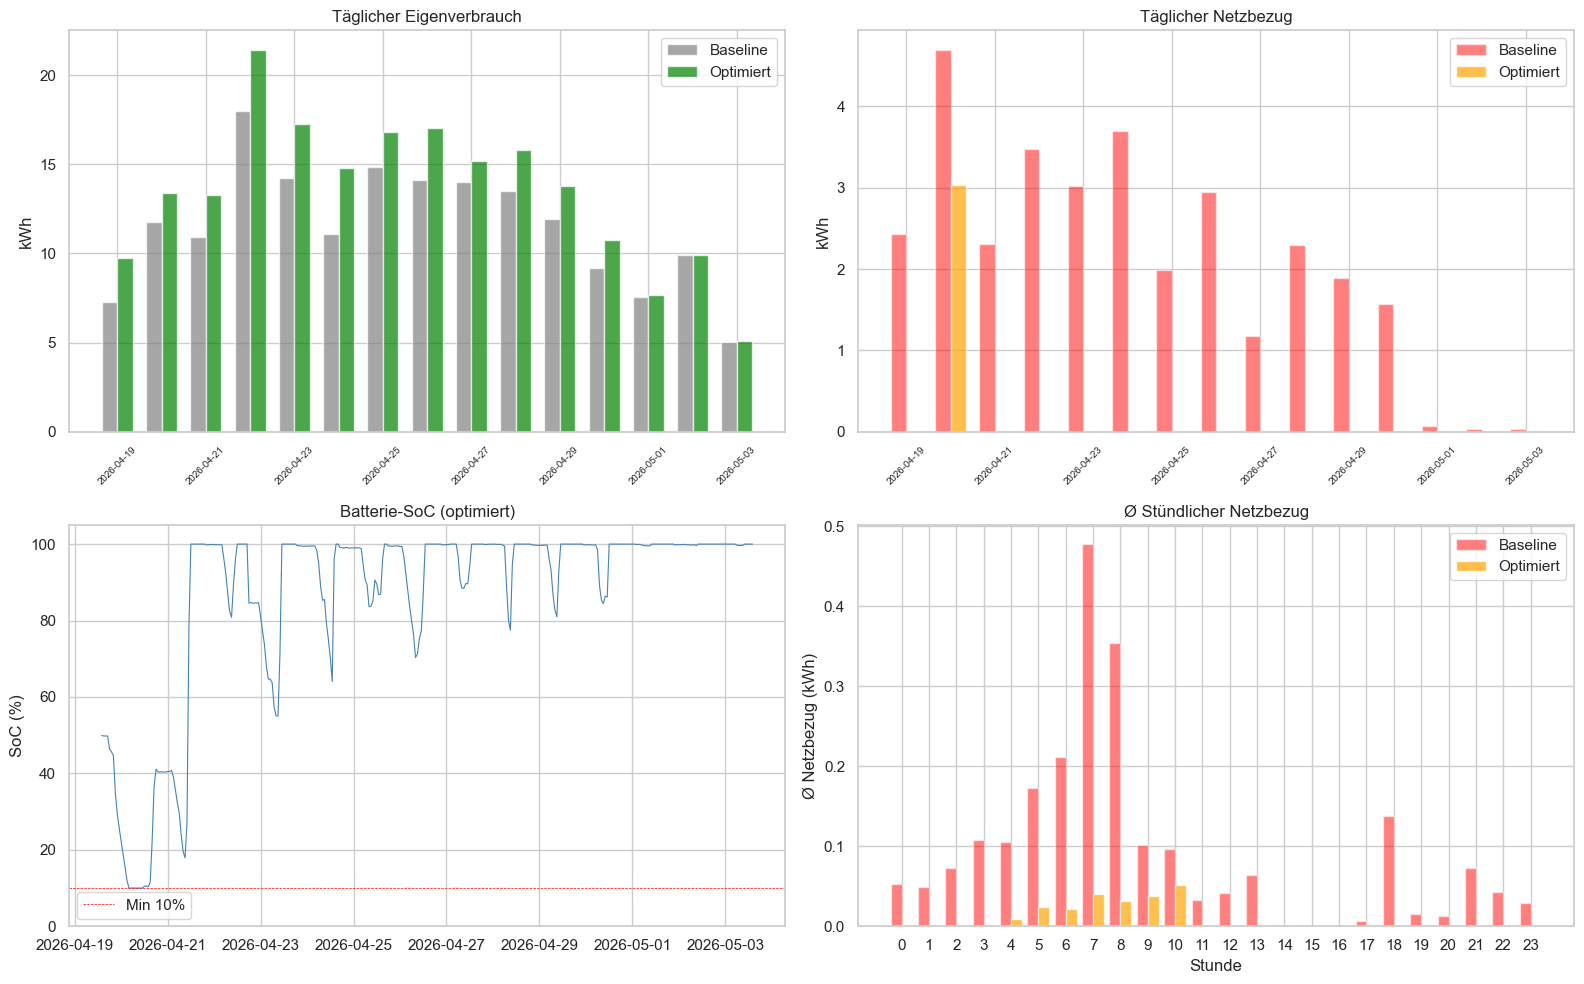

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# --- 1. Eigenverbrauch Vergleich (Tagesaggregation) ---
baseline["date"] = baseline["timestamp"].dt.date
optimized["date"] = optimized["timestamp"].dt.date

daily_base = baseline.groupby("date")[["self_consumed_kwh", "grid_import_kwh", "grid_export_kwh"]].sum()
daily_opt = optimized.groupby("date")[["self_consumed_kwh", "grid_import_kwh", "grid_export_kwh"]].sum()

x = range(len(daily_base))
w = 0.35
axes[0, 0].bar([i - w/2 for i in x], daily_base["self_consumed_kwh"], w, label="Baseline", color="gray", alpha=0.7)
axes[0, 0].bar([i + w/2 for i in x], daily_opt["self_consumed_kwh"], w, label="Optimiert", color="green", alpha=0.7)
axes[0, 0].set_ylabel("kWh")
axes[0, 0].set_title("Täglicher Eigenverbrauch")
axes[0, 0].legend()
axes[0, 0].set_xticks(list(x)[::2])
axes[0, 0].set_xticklabels([str(d) for d in daily_base.index][::2], rotation=45, fontsize=7)

# --- 2. Netzbezug Vergleich ---
axes[0, 1].bar([i - w/2 for i in x], daily_base["grid_import_kwh"], w, label="Baseline", color="red", alpha=0.5)
axes[0, 1].bar([i + w/2 for i in x], daily_opt["grid_import_kwh"], w, label="Optimiert", color="orange", alpha=0.7)
axes[0, 1].set_ylabel("kWh")
axes[0, 1].set_title("Täglicher Netzbezug")
axes[0, 1].legend()
axes[0, 1].set_xticks(list(x)[::2])
axes[0, 1].set_xticklabels([str(d) for d in daily_base.index][::2], rotation=45, fontsize=7)

# --- 3. Batterie SoC Verlauf (optimiert) ---
axes[1, 0].plot(optimized["timestamp"], optimized["battery_soc_pct"], color="steelblue", linewidth=0.8)
axes[1, 0].set_ylabel("SoC (%)")
axes[1, 0].set_title("Batterie-SoC (optimiert)")
axes[1, 0].axhline(BATTERY_MIN_SOC, color="red", linestyle="--", linewidth=0.5, label=f"Min {BATTERY_MIN_SOC}%")
axes[1, 0].set_ylim(0, 105)
axes[1, 0].legend()

# --- 4. Stündliches Profil: Baseline vs. Optimiert (Ø) ---
baseline["hour"] = baseline["timestamp"].dt.hour
optimized["hour"] = optimized["timestamp"].dt.hour

h_base = baseline.groupby("hour")["grid_import_kwh"].mean()
h_opt = optimized.groupby("hour")["grid_import_kwh"].mean()

axes[1, 1].bar([h - 0.2 for h in h_base.index], h_base.values, 0.4, label="Baseline", color="red", alpha=0.5)
axes[1, 1].bar([h + 0.2 for h in h_opt.index], h_opt.values, 0.4, label="Optimiert", color="orange", alpha=0.7)
axes[1, 1].set_xlabel("Stunde")
axes[1, 1].set_ylabel("Ø Netzbezug (kWh)")
axes[1, 1].set_title("Ø Stündlicher Netzbezug")
axes[1, 1].set_xticks(range(0, 24))
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## 5. Zusammenfassung

In [6]:
print("=" * 60)
print("BACKTESTING ZUSAMMENFASSUNG")
print("=" * 60)
print(f"Zeitraum: {hourly_w['timestamp'].min().date()} bis {hourly_w['timestamp'].max().date()} ({days:.0f} Tage)")
print(f"Batterie: {BATTERY_CAPACITY_KWH} kWh, Min-SoC: {BATTERY_MIN_SOC}%")
print(f"Strompreis: {GRID_PRICE*100:.1f} ct/kWh, Einspeisung: {FEEDIN_PRICE*100:.1f} ct/kWh")
print()
print(f"{'Metrik':<35} {'Baseline':>12} {'Optimiert':>12} {'Δ':>10}")
print("-" * 70)
for key in ["Eigenverbrauchsquote (%)", "Autarkiequote (%)", "Netzbezug (kWh)",
            "Einspeisung (kWh)", "Netto-Kosten (EUR)"]:
    b = m_base[key]
    o = m_opt[key]
    delta = o - b
    sign = "+" if delta >= 0 else ""
    print(f"{key:<35} {b:>12} {o:>12} {sign}{delta:>9.1f}")

print()
print(f"→ Kosteneinsparung: {saving:.2f} EUR ({days:.0f} Tage)")
print(f"→ Hochgerechnet: ~{saving / days * 365:.0f} EUR/Jahr")
print(f"→ Eigenverbrauchsquote: +{ev_improvement:.1f} Prozentpunkte")

BACKTESTING ZUSAMMENFASSUNG
Zeitraum: 2026-04-19 bis 2026-05-03 (14 Tage)
Batterie: 10.0 kWh, Min-SoC: 10%
Strompreis: 25.9 ct/kWh, Einspeisung: 7.9 ct/kWh

Metrik                                  Baseline    Optimiert          Δ
----------------------------------------------------------------------
Eigenverbrauchsquote (%)                    24.7         28.7 +      4.0
Autarkiequote (%)                           84.6         98.5 +     13.9
Netzbezug (kWh)                             31.6          3.0     -28.6
Einspeisung (kWh)                          529.7        496.1     -33.6
Netto-Kosten (EUR)                        -33.67       -38.41      -4.7

→ Kosteneinsparung: 4.74 EUR (14 Tage)
→ Hochgerechnet: ~124 EUR/Jahr
→ Eigenverbrauchsquote: +4.0 Prozentpunkte
